# SLA Breach Exploration

Goal: understand what drives SLA violations in `fact_work_order` and identify candidate features for a predictive model.

Data sources (Silver + Gold parquet):
- `fact_work_order` — 44,265 work orders, 9 years, ground-truth `is_sla_violation`
- `fact_alarm` — 18,702 alarm events, linkable by `site_id`
- `fact_incident` — 474 Smartti incidents
- `site_daily_signals` (Gold) — unified daily per-site signals
- `site_rolling_context` (Gold) — 7-day rolling aggregates

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

SILVER = "../luotea-pipeline/data/silver"
GOLD   = "../luotea-pipeline/data/gold"

def read_silver(table):
    path = f"{SILVER}/{table}"
    files = [f for f in os.listdir(path) if f.endswith(".parquet")]
    return pd.read_parquet(f"{path}/{files[0]}")

wo       = read_silver("fact_work_order")
alarms   = read_silver("fact_alarm")
incidents = read_silver("fact_incident")
daily    = pd.read_parquet(f"{GOLD}/site_daily_signals.parquet")
rolling  = pd.read_parquet(f"{GOLD}/site_rolling_context.parquet")

print(f"work orders : {len(wo):,}")
print(f"alarms      : {len(alarms):,}")
print(f"incidents   : {len(incidents):,}")
print(f"daily signals: {len(daily):,} site×day rows")
print(f"rolling ctx : {len(rolling):,} site×day rows")

work orders : 44,265
alarms      : 18,702
incidents   : 474
daily signals: 10,350 site×day rows
rolling ctx : 10,350 site×day rows


## 1. SLA Breach Overview

Total work orders : 44,265
SLA violations    : 23,800  (53.8%)
No violation      : 20,465  (46.2%)


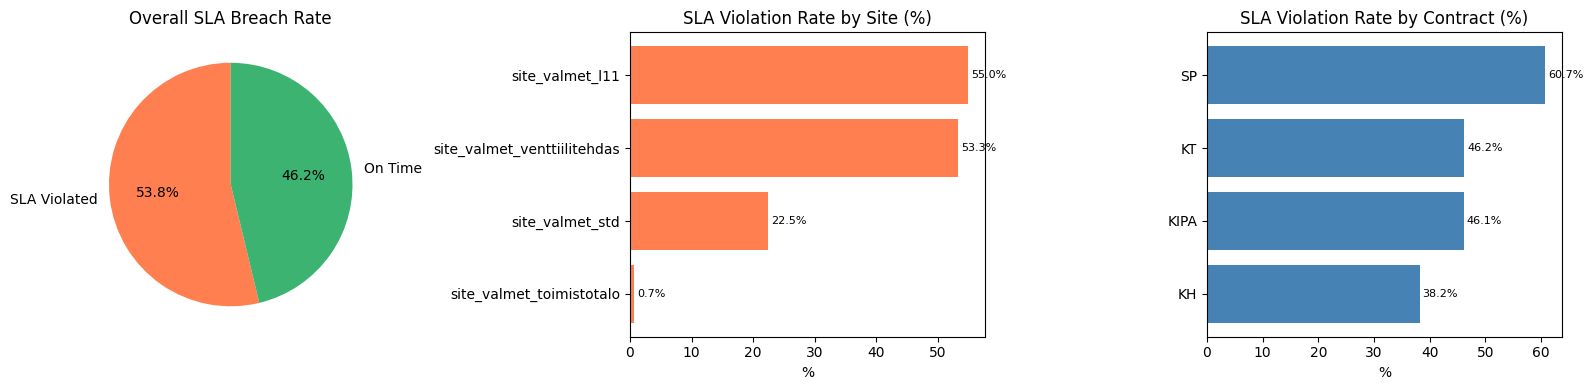

In [2]:
total = len(wo)
breached = wo["is_sla_violation"].sum()
rate = breached / total * 100
print(f"Total work orders : {total:,}")
print(f"SLA violations    : {breached:,}  ({rate:.1f}%)")
print(f"No violation      : {total - breached:,}  ({100-rate:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Overall pie
axes[0].pie([breached, total - breached], labels=["SLA Violated", "On Time"],
            colors=["coral", "mediumseagreen"], autopct="%1.1f%%", startangle=90)
axes[0].set_title("Overall SLA Breach Rate")

# By site
site_rate = (
    wo.groupby("site_id")["is_sla_violation"]
    .agg(["sum", "count"])
    .assign(rate=lambda d: d["sum"] / d["count"] * 100)
    .sort_values("rate")
)
bars = axes[1].barh(site_rate.index, site_rate["rate"], color="coral")
axes[1].set_title("SLA Violation Rate by Site (%)")
axes[1].set_xlabel("%")
for b, v in zip(bars, site_rate["rate"]):
    axes[1].text(v + 0.5, b.get_y() + b.get_height()/2, f"{v:.1f}%", va="center", fontsize=8)

# By contract type
contract_rate = (
    wo.groupby("contract_type")["is_sla_violation"]
    .agg(["sum", "count"])
    .assign(rate=lambda d: d["sum"] / d["count"] * 100)
    .sort_values("rate")
)
bars2 = axes[2].barh(contract_rate.index, contract_rate["rate"], color="steelblue")
axes[2].set_title("SLA Violation Rate by Contract (%)")
axes[2].set_xlabel("%")
for b, v in zip(bars2, contract_rate["rate"]):
    axes[2].text(v + 0.5, b.get_y() + b.get_height()/2, f"{v:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

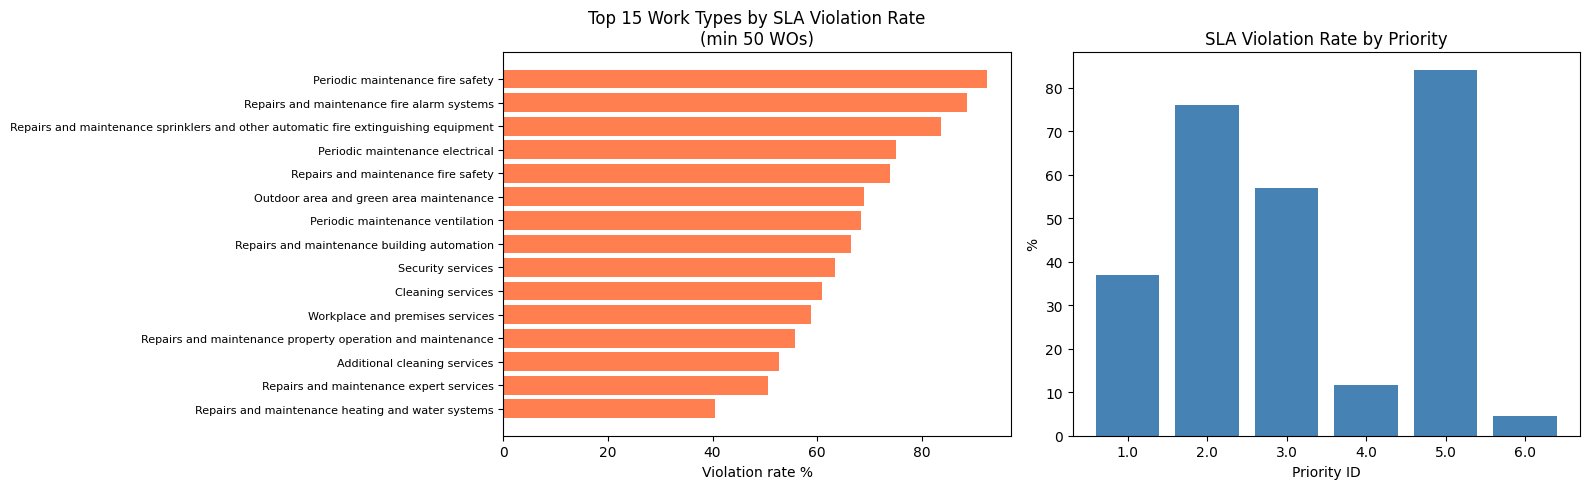

In [3]:
# By work type (top 15)
wtype_rate = (
    wo.groupby("work_type_eng")["is_sla_violation"]
    .agg(["sum", "count"])
    .assign(rate=lambda d: d["sum"] / d["count"] * 100)
)
# Only types with enough volume
wtype_rate = wtype_rate[wtype_rate["count"] >= 50].sort_values("rate", ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(wtype_rate.index[::-1], wtype_rate["rate"][::-1], color="coral")
axes[0].set_title("Top 15 Work Types by SLA Violation Rate\n(min 50 WOs)")
axes[0].set_xlabel("Violation rate %")
axes[0].tick_params(axis="y", labelsize=8)

# By priority
prio_rate = (
    wo[wo["priority_id"].notna()]
    .groupby("priority_id")["is_sla_violation"]
    .agg(["sum", "count"])
    .assign(rate=lambda d: d["sum"] / d["count"] * 100)
    .sort_index()
)
axes[1].bar(prio_rate.index.astype(str), prio_rate["rate"], color="steelblue")
axes[1].set_title("SLA Violation Rate by Priority")
axes[1].set_xlabel("Priority ID")
axes[1].set_ylabel("%")

plt.tight_layout()
plt.show()

## 2. Temporal Patterns

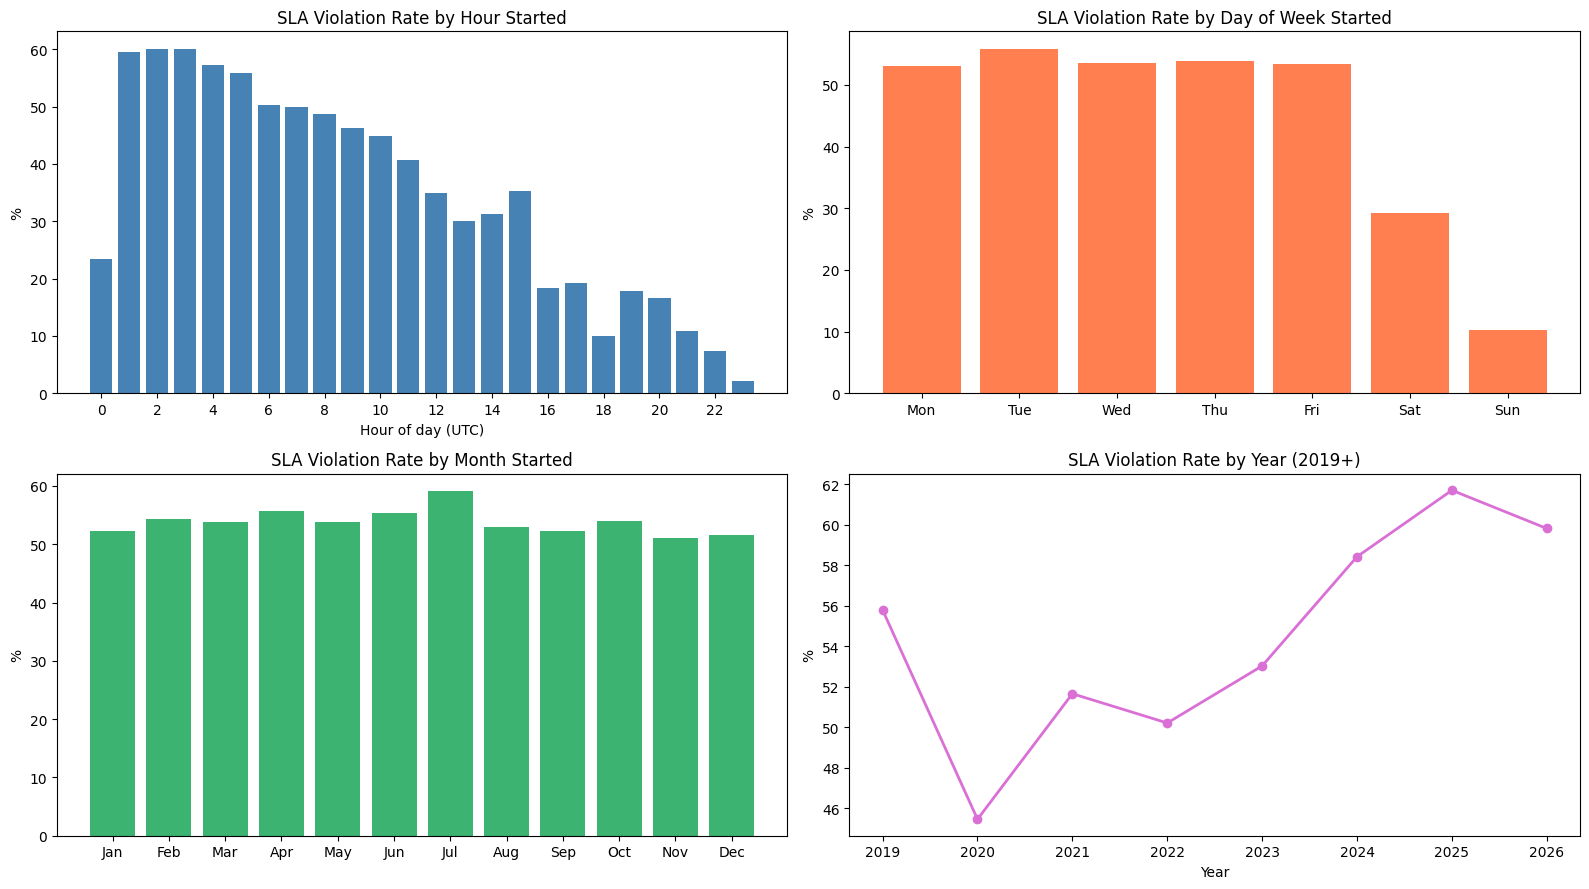

In [4]:
wo["started_date"] = wo["work_started_at_utc"].dt.date
wo["started_hour"] = wo["work_started_at_utc"].dt.hour
wo["started_dow"] = wo["work_started_at_utc"].dt.day_of_week  # 0=Mon
wo["started_month"] = wo["work_started_at_utc"].dt.month
wo["started_year"] = wo["work_started_at_utc"].dt.year

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# Hour of day
hour_rate = (
    wo.groupby("started_hour")["is_sla_violation"]
    .agg(["sum", "count"])
    .assign(rate=lambda d: d["sum"] / d["count"] * 100)
)
axes[0, 0].bar(hour_rate.index, hour_rate["rate"], color="steelblue")
axes[0, 0].set_title("SLA Violation Rate by Hour Started")
axes[0, 0].set_xlabel("Hour of day (UTC)")
axes[0, 0].set_ylabel("%")
axes[0, 0].set_xticks(range(0, 24, 2))

# Day of week
dow_rate = (
    wo.groupby("started_dow")["is_sla_violation"]
    .agg(["sum", "count"])
    .assign(rate=lambda d: d["sum"] / d["count"] * 100)
)
axes[0, 1].bar([dow_labels[i] for i in dow_rate.index], dow_rate["rate"], color="coral")
axes[0, 1].set_title("SLA Violation Rate by Day of Week Started")
axes[0, 1].set_ylabel("%")

# Month
month_rate = (
    wo.groupby("started_month")["is_sla_violation"]
    .agg(["sum", "count"])
    .assign(rate=lambda d: d["sum"] / d["count"] * 100)
)
axes[1, 0].bar([month_labels[m-1] for m in month_rate.index], month_rate["rate"], color="mediumseagreen")
axes[1, 0].set_title("SLA Violation Rate by Month Started")
axes[1, 0].set_ylabel("%")

# Yearly trend
year_rate = (
    wo[wo["started_year"] >= 2019]
    .groupby("started_year")["is_sla_violation"]
    .agg(["sum", "count"])
    .assign(rate=lambda d: d["sum"] / d["count"] * 100)
)
axes[1, 1].plot(year_rate.index, year_rate["rate"], marker="o", color="orchid", linewidth=2)
axes[1, 1].set_title("SLA Violation Rate by Year (2019+)")
axes[1, 1].set_ylabel("%")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_xticks(year_rate.index)

plt.tight_layout()
plt.show()

## 3. Work Order Duration & Worktime Features

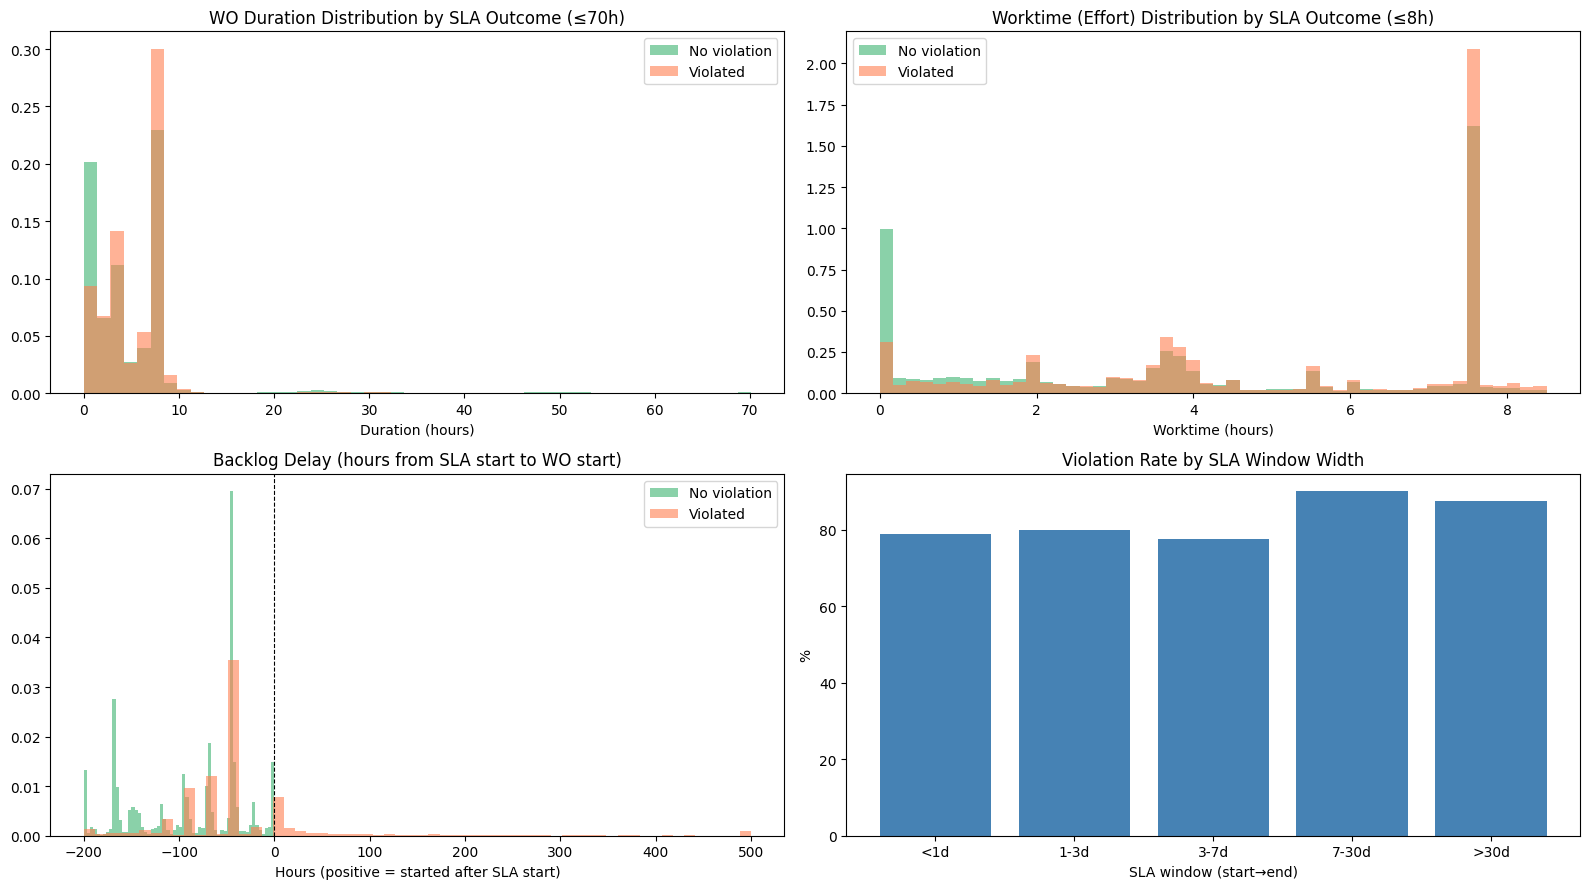

Duration median (hours):
is_sla_violation
False    4.3
True     6.5
Name: duration_h, dtype: float64

Worktime median (hours):
is_sla_violation
False    3.8
True     5.6
Name: worktime_hours, dtype: float64


In [5]:
# Compute duration from start to finish in hours
wo["duration_h"] = (
    (wo["work_finished_at_utc"] - wo["work_started_at_utc"])
    .dt.total_seconds() / 3600
)

# Compute time from SLA start to work start (backlog delay)
wo["sla_backlog_h"] = (
    (wo["work_started_at_utc"] - wo["sla_required_start_at_utc"])
    .dt.total_seconds() / 3600
)

# Compute SLA window width
wo["sla_window_h"] = (
    (wo["sla_required_end_at_utc"] - wo["sla_required_start_at_utc"])
    .dt.total_seconds() / 3600
)

cap_d = wo["duration_h"].quantile(0.95)
cap_w = wo["worktime_hours"].quantile(0.95)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# Duration distribution by breach
for label, color, mask in [
    ("No violation", "mediumseagreen", ~wo["is_sla_violation"]),
    ("Violated",     "coral",          wo["is_sla_violation"]),
]:
    d = wo.loc[mask & (wo["duration_h"] <= cap_d), "duration_h"].dropna()
    axes[0, 0].hist(d, bins=50, alpha=0.6, color=color, label=label, density=True)
axes[0, 0].set_title(f"WO Duration Distribution by SLA Outcome (≤{cap_d:.0f}h)")
axes[0, 0].set_xlabel("Duration (hours)")
axes[0, 0].legend()

# Worktime distribution by breach
for label, color, mask in [
    ("No violation", "mediumseagreen", ~wo["is_sla_violation"]),
    ("Violated",     "coral",          wo["is_sla_violation"]),
]:
    d = wo.loc[mask & (wo["worktime_hours"] <= cap_w), "worktime_hours"].dropna()
    axes[0, 1].hist(d, bins=50, alpha=0.6, color=color, label=label, density=True)
axes[0, 1].set_title(f"Worktime (Effort) Distribution by SLA Outcome (≤{cap_w:.0f}h)")
axes[0, 1].set_xlabel("Worktime (hours)")
axes[0, 1].legend()

# Backlog delay at start (positive = started late vs SLA start)
backlog = wo[(wo["sla_backlog_h"].notna()) & (wo["sla_backlog_h"].abs() < 1000)]
for label, color, mask in [
    ("No violation", "mediumseagreen", ~backlog["is_sla_violation"]),
    ("Violated",     "coral",          backlog["is_sla_violation"]),
]:
    axes[1, 0].hist(backlog.loc[mask, "sla_backlog_h"].clip(-200, 500), bins=60,
                    alpha=0.6, color=color, label=label, density=True)
axes[1, 0].axvline(0, color="black", linestyle="--", linewidth=0.8)
axes[1, 0].set_title("Backlog Delay (hours from SLA start to WO start)")
axes[1, 0].set_xlabel("Hours (positive = started after SLA start)")
axes[1, 0].legend()

# SLA window width vs breach rate
window = wo[(wo["sla_window_h"].notna()) & (wo["sla_window_h"] > 0) & (wo["sla_window_h"] < 5000)].copy()
window["window_bin"] = pd.cut(window["sla_window_h"], bins=[0,24,72,168,720,5000],
                               labels=["<1d","1-3d","3-7d","7-30d",">30d"])
win_rate = (
    window.groupby("window_bin", observed=True)["is_sla_violation"]
    .agg(["sum", "count"])
    .assign(rate=lambda d: d["sum"] / d["count"] * 100)
)
axes[1, 1].bar(win_rate.index.astype(str), win_rate["rate"], color="steelblue")
axes[1, 1].set_title("Violation Rate by SLA Window Width")
axes[1, 1].set_xlabel("SLA window (start→end)")
axes[1, 1].set_ylabel("%")

plt.tight_layout()
plt.show()

print("Duration median (hours):")
print(wo.groupby("is_sla_violation")["duration_h"].median().round(1))
print("\nWorktime median (hours):")
print(wo.groupby("is_sla_violation")["worktime_hours"].median().round(1))

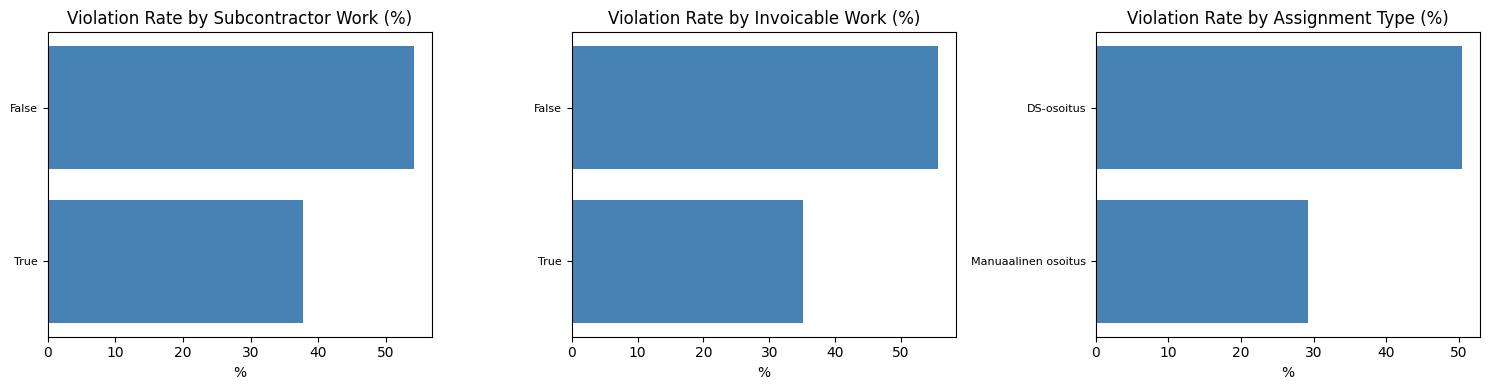

In [6]:
# Subcontractor and invoicable flags
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in [
    (axes[0], "is_subcontractor_work", "Subcontractor Work"),
    (axes[1], "is_invoicable",         "Invoicable Work"),
    (axes[2], "assignment_type",       "Assignment Type"),
]:
    rate = (
        wo.groupby(col)["is_sla_violation"]
        .agg(["sum", "count"])
        .assign(rate=lambda d: d["sum"] / d["count"] * 100)
        .sort_values("rate")
    )
    ax.barh(rate.index.astype(str), rate["rate"], color="steelblue")
    ax.set_title(f"Violation Rate by {title} (%)")
    ax.set_xlabel("%")
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

## 4. Pre-Work-Order Alarm Density

Hypothesis: sites with more alarms in the days before a work order starts are more likely to breach SLA (overwhelmed capacity).

WOs with daily signal match: 44,265 / 44,265


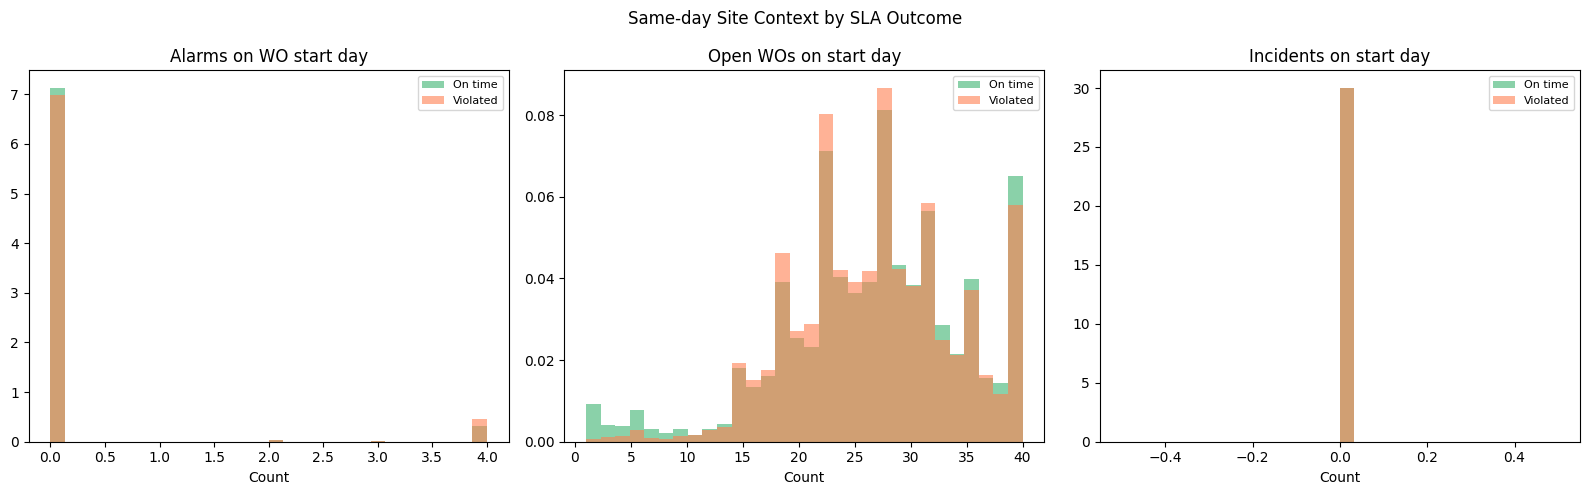


Median same-day site signals by SLA outcome:
                  alarm_count  fire_alarm_count  hvac_alarm_count  open_work_orders  incident_count
is_sla_violation                                                                                   
False                     0.0               0.0               0.0              27.0             0.0
True                      0.0               0.0               0.0              27.0             0.0


In [7]:
# Use the gold daily signals which already aggregate alarm_count per site×day
daily["signal_date"] = pd.to_datetime(daily["signal_date"])

wo_with_date = wo.dropna(subset=["work_started_at_utc", "site_id"]).copy()
wo_with_date["wo_date"] = wo_with_date["work_started_at_utc"].dt.tz_convert(None).dt.normalize()

# Join: for each WO, look up same-day site signals
daily_for_join = daily[["site_id", "signal_date", "alarm_count", "fire_alarm_count",
                         "hvac_alarm_count", "open_work_orders", "incident_count",
                         "avg_co2_ppm", "avg_indoor_temp_c", "avg_room_utilization_pct",
                         "avg_desk_utilization_pct"]].copy()

wo_enriched = wo_with_date.merge(
    daily_for_join,
    left_on=["site_id", "wo_date"],
    right_on=["site_id", "signal_date"],
    how="left",
)

print(f"WOs with daily signal match: {wo_enriched['alarm_count'].notna().sum():,} / {len(wo_enriched):,}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, label in [
    (axes[0], "alarm_count",      "Alarms on WO start day"),
    (axes[1], "open_work_orders", "Open WOs on start day"),
    (axes[2], "incident_count",   "Incidents on start day"),
]:
    matched = wo_enriched[wo_enriched[col].notna()]
    cap = matched[col].quantile(0.95)
    for breach, color in [(False, "mediumseagreen"), (True, "coral")]:
        d = matched.loc[matched["is_sla_violation"] == breach, col].clip(0, cap)
        ax.hist(d, bins=30, alpha=0.6, color=color,
                label="Violated" if breach else "On time", density=True)
    ax.set_title(label)
    ax.set_xlabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Same-day Site Context by SLA Outcome", fontsize=12)
plt.tight_layout()
plt.show()

# Median comparison
ctx_cols = ["alarm_count", "fire_alarm_count", "hvac_alarm_count",
            "open_work_orders", "incident_count"]
print("\nMedian same-day site signals by SLA outcome:")
print(wo_enriched.groupby("is_sla_violation")[ctx_cols].median().round(2).to_string())

In [8]:
# Add rolling 7-day context to work orders
rolling["as_of_date"] = pd.to_datetime(rolling["as_of_date"])

wo_enriched2 = wo_enriched.merge(
    rolling,
    left_on=["site_id", "wo_date"],
    right_on=["site_id", "as_of_date"],
    how="left",
)

roll_cols = ["open_wo_7d_avg", "sla_violations_7d", "alarms_7d_avg",
             "fire_alarms_7d", "incidents_7d", "utilization_7d_avg"]
print("Median 7-day rolling context by SLA outcome:")
print(wo_enriched2.groupby("is_sla_violation")[roll_cols].median().round(2).to_string())

Median 7-day rolling context by SLA outcome:
                  open_wo_7d_avg  sla_violations_7d  alarms_7d_avg  fire_alarms_7d  incidents_7d  utilization_7d_avg
is_sla_violation                                                                                                    
False                      22.43               34.0            0.0             0.0           0.0               37.16
True                       22.29               37.0            0.0             0.0           0.0               36.83


## 5. Environmental Signals (CO₂, Temperature, Utilization)

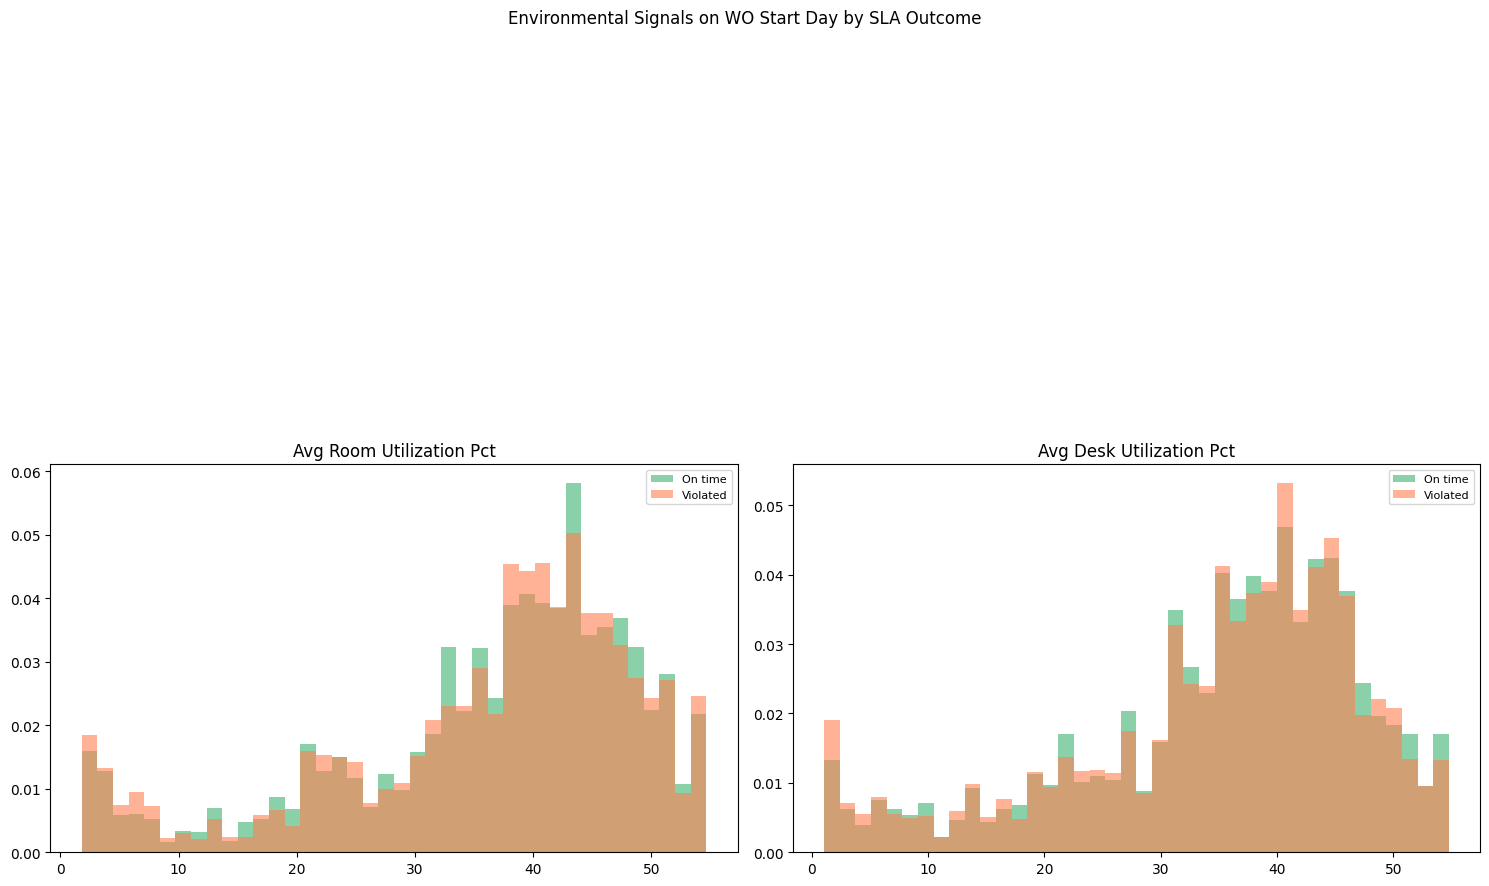

Median environmental signals by SLA outcome:
                  avg_co2_ppm  avg_indoor_temp_c  avg_room_utilization_pct  avg_desk_utilization_pct
is_sla_violation                                                                                    
False                     NaN                NaN                     39.50                     37.92
True                      NaN                NaN                     39.56                     37.97


In [9]:
env_cols = ["avg_co2_ppm", "avg_indoor_temp_c",
            "avg_room_utilization_pct", "avg_desk_utilization_pct"]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for ax, col in zip(axes, env_cols):
    matched = wo_enriched[wo_enriched[col].notna()]
    if len(matched) == 0:
        ax.set_visible(False)
        continue
    cap = matched[col].quantile(0.99)
    low = matched[col].quantile(0.01)
    for breach, color in [(False, "mediumseagreen"), (True, "coral")]:
        d = matched.loc[matched["is_sla_violation"] == breach, col].clip(low, cap)
        ax.hist(d, bins=40, alpha=0.6, color=color,
                label="Violated" if breach else "On time", density=True)
    ax.set_title(col.replace("_", " ").title())
    ax.legend(fontsize=8)

plt.suptitle("Environmental Signals on WO Start Day by SLA Outcome", fontsize=12)
plt.tight_layout()
plt.show()

print("Median environmental signals by SLA outcome:")
print(wo_enriched.groupby("is_sla_violation")[env_cols].median().round(2).to_string())

## 6. Alarm Type Before Work Order

Join alarms to work orders by site and look at alarm density in the 7 days preceding each work order.

In [10]:
# Alarm rates by type per site × day — then merge as a feature
alarms["alarm_date"] = alarms["event_time_utc"].dt.tz_convert(None).dt.normalize()

alarm_daily = (
    alarms[alarms["alert_type"].notna()].groupby(["site_id", "alarm_date", "alert_type"])
    .size()
    .reset_index(name="alarm_n")
    .pivot_table(index=["site_id", "alarm_date"], columns="alert_type", values="alarm_n", fill_value=0)
    .reset_index()
)
alarm_daily.columns = [f"alarm_{c}" if c not in ("site_id", "alarm_date") else c
                       for c in alarm_daily.columns]
print("Alarm type columns:", [c for c in alarm_daily.columns if c.startswith("alarm_")])

wo_alarms = wo_with_date.merge(
    alarm_daily,
    left_on=["site_id", "wo_date"],
    right_on=["site_id", "alarm_date"],
    how="left",
)

alarm_type_cols = [c for c in wo_alarms.columns if c.startswith("alarm_") and c != "alarm_date"]
print("\nMedian alarm type counts on WO start day by SLA outcome:")
print(wo_alarms.groupby("is_sla_violation")[alarm_type_cols].median().round(2).to_string())

Alarm type columns: ['alarm_date', 'alarm_HÄLYT', 'alarm_INFO', 'alarm_LINJAVIK', 'alarm_LVIA', 'alarm_LVIS', 'alarm_Lvi-häly', 'alarm_PALO', 'alarm_PALOVIK']

Median alarm type counts on WO start day by SLA outcome:
                  alarm_HÄLYT  alarm_INFO  alarm_LINJAVIK  alarm_LVIA  alarm_LVIS  alarm_Lvi-häly  alarm_PALO  alarm_PALOVIK
is_sla_violation                                                                                                            
False                     4.0         0.0             0.0         0.0         0.0             0.0         0.0            0.0
True                      4.0         0.0             0.0         0.0         0.0             0.0         0.0            0.0


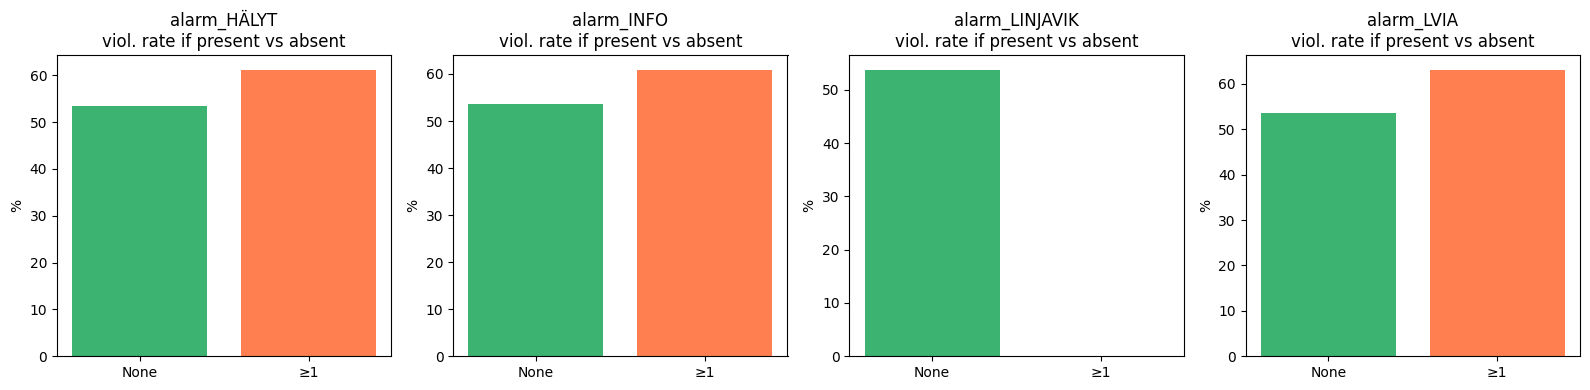

In [11]:
# Alarm type × SLA violation rate: for each alarm type, if any alarm fired on that day
if alarm_type_cols:
    n_cols = len(alarm_type_cols)
    fig, axes = plt.subplots(1, min(n_cols, 4), figsize=(16, 4))
    if n_cols == 1:
        axes = [axes]
    for ax, col in zip(axes, alarm_type_cols[:4]):
        wo_alarms[f"has_{col}"] = wo_alarms[col].fillna(0).astype(float) > 0
        rate = (
            wo_alarms.groupby(f"has_{col}")["is_sla_violation"]
            .agg(["sum", "count"])
            .assign(rate=lambda d: d["sum"] / d["count"] * 100)
        )
        ax.bar(["None", "≥1"], rate["rate"].values, color=["mediumseagreen", "coral"])
        ax.set_title(f"{col}\nviol. rate if present vs absent")
        ax.set_ylabel("%")
    plt.tight_layout()
    plt.show()

## 7. Feature Correlation Summary

Quick numeric correlation between candidate features and the breach label.

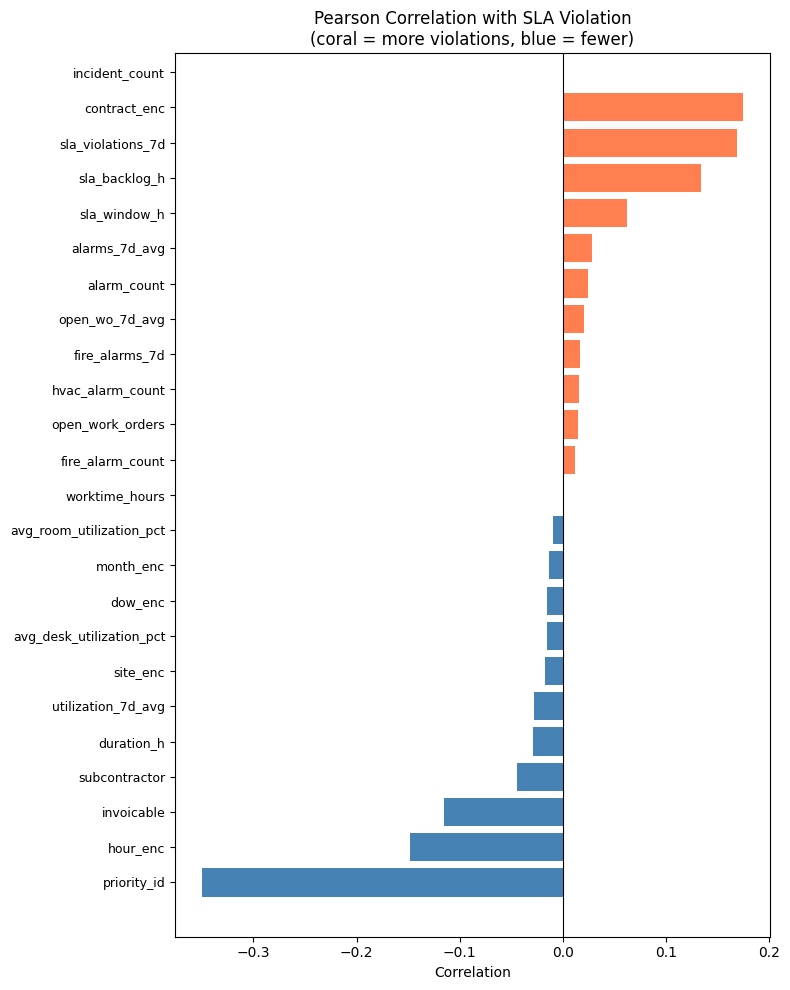


Top positive correlators (→ more breaches):
alarm_count          0.0243
alarms_7d_avg        0.0287
sla_window_h         0.0621
sla_backlog_h        0.1336
sla_violations_7d    0.1690
contract_enc         0.1743
incident_count          NaN
avg_co2_ppm             NaN
avg_indoor_temp_c       NaN
incidents_7d            NaN

Top negative correlators (→ fewer breaches):
priority_id                -0.3499
hour_enc                   -0.1480
invoicable                 -0.1157
subcontractor              -0.0447
duration_h                 -0.0291
utilization_7d_avg         -0.0279
site_enc                   -0.0173
avg_desk_utilization_pct   -0.0153
dow_enc                    -0.0152
month_enc                  -0.0132


In [12]:
# Build a flat feature matrix from enriched WOs
feature_df = wo_enriched2.copy()
feature_df["sla_violated"] = feature_df["is_sla_violation"].astype(int)

# Encode categoricals
feature_df["contract_enc"] = feature_df["contract_type"].astype("category").cat.codes
feature_df["site_enc"]     = feature_df["site_id"].astype("category").cat.codes
feature_df["dow_enc"]      = feature_df["started_dow"]
feature_df["hour_enc"]     = feature_df["started_hour"]
feature_df["month_enc"]    = feature_df["started_month"]
feature_df["subcontractor"] = feature_df["is_subcontractor_work"].astype(int)
feature_df["invoicable"]   = feature_df["is_invoicable"].astype(int)

candidate_features = [
    "sla_violated",
    # WO intrinsic
    "priority_id", "worktime_hours", "duration_h", "sla_backlog_h", "sla_window_h",
    "subcontractor", "invoicable",
    # Temporal
    "dow_enc", "hour_enc", "month_enc",
    # Site encoding
    "contract_enc", "site_enc",
    # Same-day signals
    "alarm_count", "fire_alarm_count", "hvac_alarm_count",
    "open_work_orders", "incident_count",
    "avg_co2_ppm", "avg_indoor_temp_c",
    "avg_room_utilization_pct", "avg_desk_utilization_pct",
    # Rolling 7-day
    "open_wo_7d_avg", "sla_violations_7d", "alarms_7d_avg",
    "fire_alarms_7d", "incidents_7d", "utilization_7d_avg",
]

feat_cols = [c for c in candidate_features if c in feature_df.columns]
corr = feature_df[feat_cols].corr()["sla_violated"].drop("sla_violated").sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
colors = ["coral" if v > 0 else "steelblue" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation with SLA Violation\n(coral = more violations, blue = fewer)")
ax.set_xlabel("Correlation")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

print("\nTop positive correlators (→ more breaches):")
print(corr.tail(10).round(4).to_string())
print("\nTop negative correlators (→ fewer breaches):")
print(corr.head(10).round(4).to_string())

## 8. Monthly SLA Breach Trend (per site)

/tmp/ipykernel_128427/4192960823.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  wo["period"] = wo["work_started_at_utc"].dt.to_period("M")


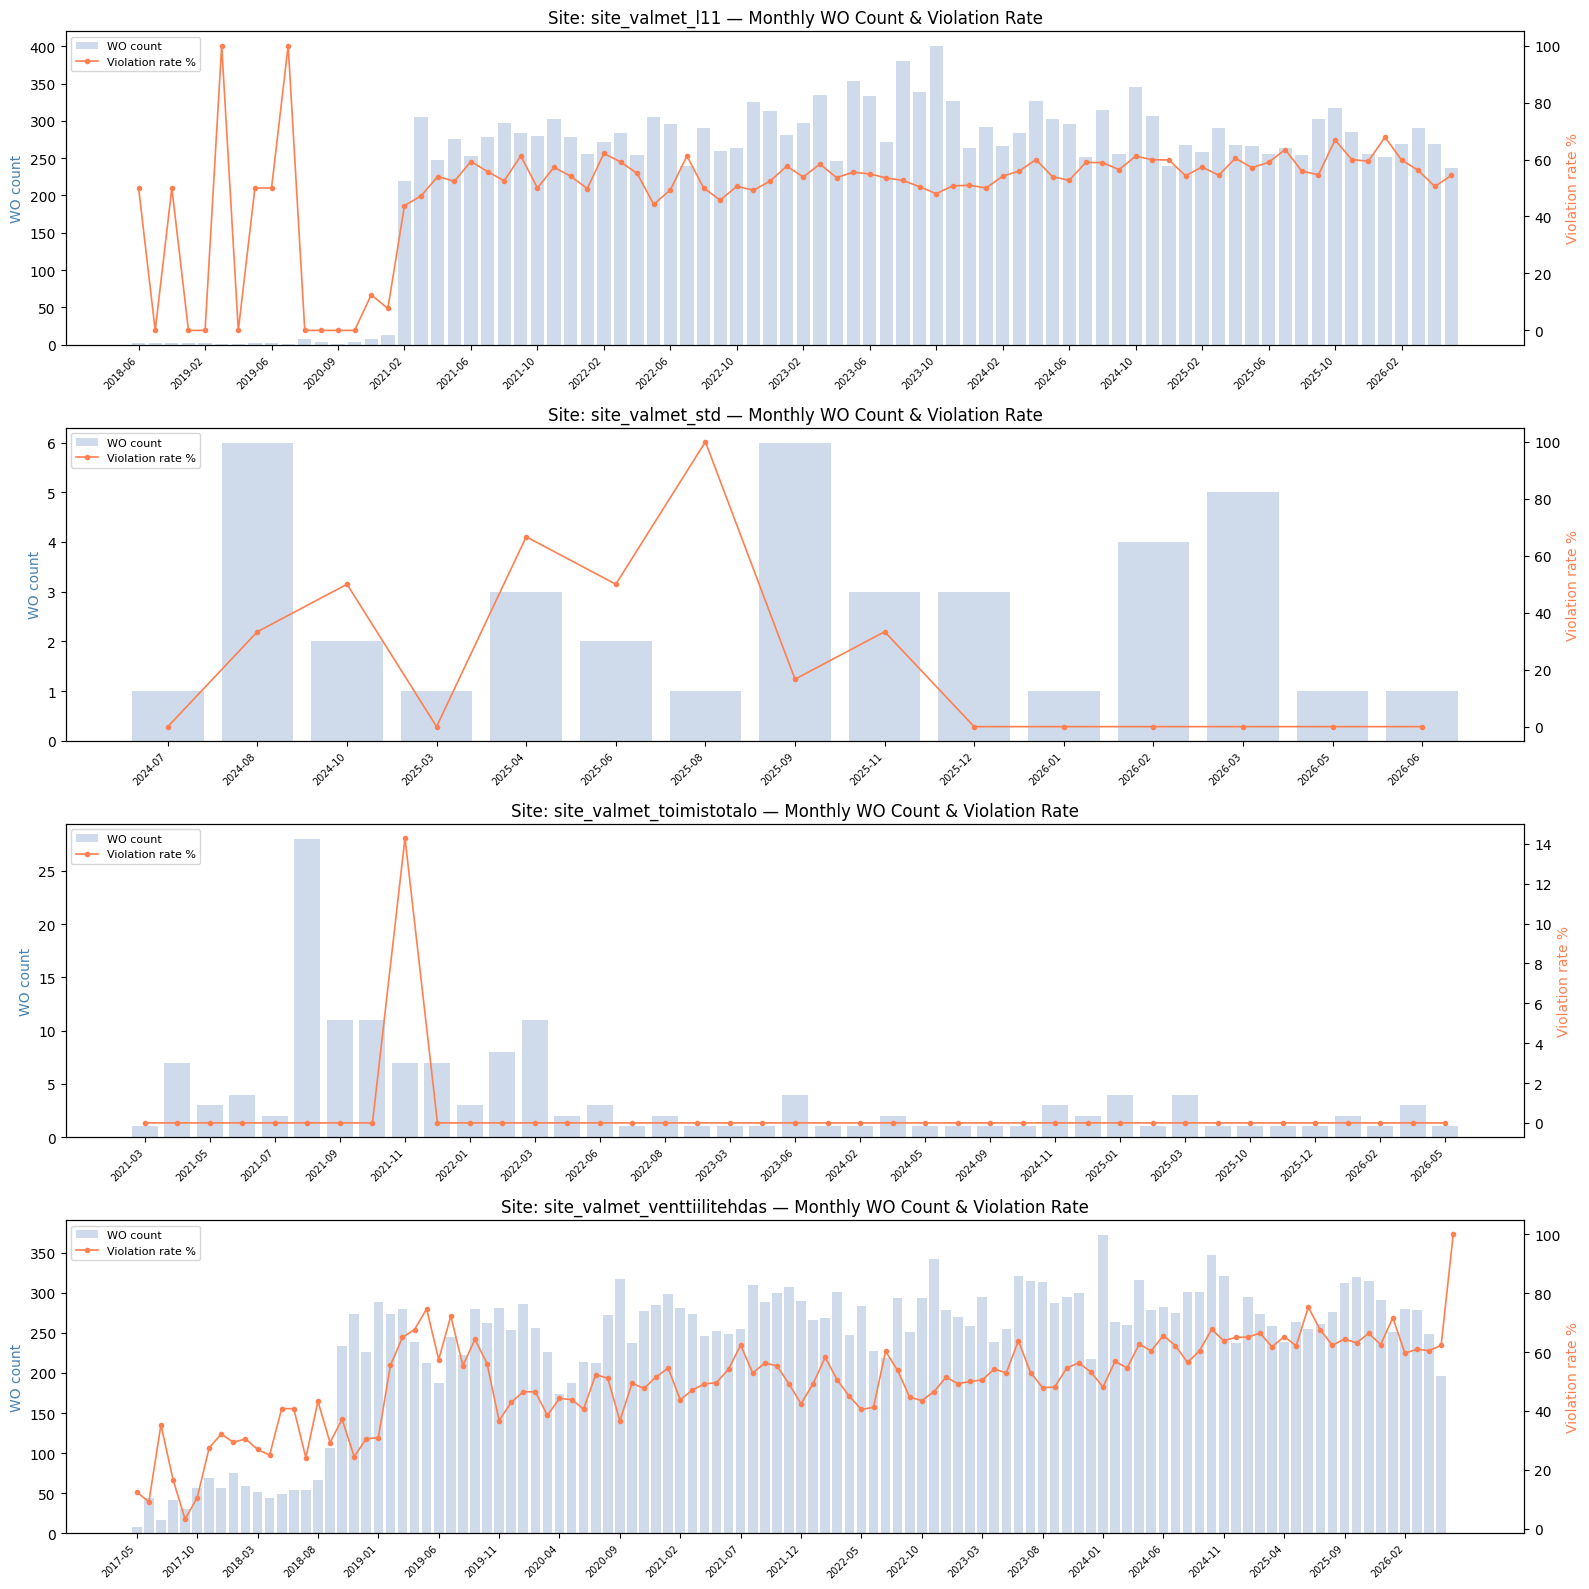

In [13]:
wo["period"] = wo["work_started_at_utc"].dt.to_period("M")

sites = wo["site_id"].dropna().unique()
n = len(sites)
fig, axes = plt.subplots(n, 1, figsize=(16, 4 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, site in zip(axes, sorted(sites)):
    sub = wo[wo["site_id"] == site]
    monthly = (
        sub.groupby("period")["is_sla_violation"]
        .agg(["sum", "count"])
        .assign(rate=lambda d: d["sum"] / d["count"] * 100)
        .sort_index()
    )
    ax2 = ax.twinx()
    ax.bar(monthly.index.astype(str), monthly["count"], color="lightsteelblue",
           alpha=0.6, label="WO count")
    ax2.plot(monthly.index.astype(str), monthly["rate"], color="coral",
             marker=".", linewidth=1.2, label="Violation rate %")
    ax.set_title(f"Site: {site} — Monthly WO Count & Violation Rate")
    ax.set_ylabel("WO count", color="steelblue")
    ax2.set_ylabel("Violation rate %", color="coral")
    step = max(1, len(monthly) // 20)
    ax.set_xticks(range(0, len(monthly), step))
    ax.set_xticklabels(
        [str(p) for p in monthly.index[::step]], rotation=45, ha="right", fontsize=7
    )
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## 9. Candidate Features Summary

Summary of features worth including in the SLA breach model, based on the exploration above.

In [14]:
summary = {
    "Feature group": [
        "WO intrinsic",
        "WO intrinsic",
        "WO intrinsic",
        "WO intrinsic",
        "WO intrinsic",
        "WO intrinsic",
        "Temporal",
        "Temporal",
        "Temporal",
        "Site context (same day)",
        "Site context (same day)",
        "Site context (same day)",
        "Environmental (same day)",
        "Environmental (same day)",
        "Rolling 7-day",
        "Rolling 7-day",
        "Rolling 7-day",
    ],
    "Feature": [
        "priority_id",
        "worktime_hours",
        "sla_window_h (end−start)",
        "sla_backlog_h (WO start − SLA start)",
        "is_subcontractor_work",
        "contract_type",
        "day_of_week",
        "hour_of_day",
        "month",
        "alarm_count",
        "open_work_orders",
        "incident_count",
        "avg_co2_ppm",
        "avg_indoor_temp_c",
        "sla_violations_7d",
        "open_wo_7d_avg",
        "alarms_7d_avg",
    ],
    "Available at predict time?": [
        "Yes", "No (outcome)", "Yes", "Yes", "Yes", "Yes",
        "Yes", "Yes", "Yes",
        "Yes (rolling up to now)", "Yes", "Yes",
        "Yes", "Yes",
        "Yes", "Yes", "Yes",
    ],
    "Notes": [
        "71% null — impute with median or drop",
        "Only known after completion — use as insight, not model input",
        "Tighter window → higher risk",
        "How late was the WO started vs SLA start",
        "Different resource pool",
        "SP vs KH vs KT vs KIPA have very different rates",
        "Mon–Fri vs weekend pattern",
        "Night/early morning WOs may run longer",
        "Seasonal maintenance peaks",
        "High alarm day = busy site",
        "Backlog proxy",
        "Smartti sites only",
        "Smartti sites only — comfort proxy",
        "Smartti sites only",
        "Recent breach history",
        "Rolling backlog",
        "Rolling alarm pressure",
    ],
}

summary_df = pd.DataFrame(summary)
summary_df

,Feature group,Feature,Available at predict time?,Notes
0,WO intrinsic,priority_id,Yes,71% null — impute with median or drop
1,WO intrinsic,worktime_hours,No (outcome),"Only known after completion — use as insight, ..."
2,WO intrinsic,sla_window_h (end−start),Yes,Tighter window → higher risk
3,WO intrinsic,sla_backlog_h (WO start − SLA start),Yes,How late was the WO started vs SLA start
4,WO intrinsic,is_subcontractor_work,Yes,Different resource pool
5,WO intrinsic,contract_type,Yes,SP vs KH vs KT vs KIPA have very different rates
6,Temporal,day_of_week,Yes,Mon–Fri vs weekend pattern
7,Temporal,hour_of_day,Yes,Night/early morning WOs may run longer
8,Temporal,month,Yes,Seasonal maintenance peaks
9,Site context (same day),alarm_count,Yes (rolling up to now),High alarm day = busy site
